In [1]:
# ─── STEP 0: Install all dependencies ───────────────────────────────────────
# Run this cell once before anything else
%pip install -q langgraph langchain langchain-groq langchain-community tavily-python pydantic
%pip install -q grandalf  # needed for draw_mermaid_png fallback

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
# ─── STEP 1: Set API keys ────────────────────────────────────────────────────
# Option A — hardcode for local testing (never commit this to git)
import os
# os.environ['GROQ_API_KEY']   = 'your_groq_api_key_here'
# os.environ['TAVILY_API_KEY'] = 'your_tavily_api_key_here'

# Option B — load from .env file (recommended)
from dotenv import load_dotenv
load_dotenv()  # reads GROQ_API_KEY and TAVILY_API_KEY from .env

True

In [3]:
# ─── STEP 2: Define State and Router schema ────────────────────────────────
import operator
from typing import Annotated, List, TypedDict, Literal
from pydantic import BaseModel, Field

# The State object that travels through the graph
class AgentState(TypedDict):
    task: str
    research_notes: Annotated[List[str], operator.add]
    draft: str
    next_node: str
    retry_count: int
    revision_feedback: str

# Schema for the Supervisor to follow
class Router(BaseModel):
    """Decide which worker to call next."""
    next_worker: Literal["researcher", "writer", "FINISH"] = Field(description="The next node to act")
    instructions: str = Field(description="Specific instructions for the worker")
    is_critical: bool = Field(description="If True, system will pause for human review")

In [4]:
# ─── STEP 3: LLM, Tools, and Agent functions ───────────────────────────────
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

# Using Llama 3.3 70B for the "Brain" (Supervisor)
llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0)
search_tool = TavilySearchResults(k=2)

def researcher(state: AgentState):
    print("🚀 Researcher is digging...")
    query = state['task']
    results = search_tool.invoke(query)
    print(results)
    return {"research_notes": [str(results)], "retry_count": 0}

def writer(state: AgentState):
    print("✍️ Writer is composing...")
    context = "\n".join(state['research_notes'])
    res = llm.invoke(f"Write a report on {state['task']} using: {context}")
    return {"draft": res.content}

def supervisor(state: AgentState):
    print("🧠 Supervisor is reviewing state...")
    # Groq supports structured output natively
    structured_llm = llm.with_structured_output(Router)

    prompt = f"""
    Task: {state['task']}
    Notes collected: {len(state['research_notes'])}
    Current Draft: {state['draft'][:100]}...
    If you have something in research_notes, select writer
    """
    print(f"Supervisor sees {len(state['research_notes'])} notes and draft length {len(state['draft'])}")
    decision = structured_llm.invoke(prompt)
    return {
        "next_node": decision.next_worker,
        "revision_feedback": decision.instructions
    }

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2180\2659532588.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\Administrator\AppData\Local\Temp\ipykernel_2180\2659532588.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(k=2)


In [5]:
# ─── STEP 4: Build and compile the LangGraph ───────────────────────────────
# Graph with recovery and breakpoints
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(AgentState)

# Add nodes
builder.add_node("supervisor", supervisor)
builder.add_node("researcher", researcher)
builder.add_node("writer", writer)

# Logic
builder.set_entry_point("supervisor")

builder.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {"researcher": "researcher", "writer": "writer", "FINISH": END}
)

builder.add_edge("researcher", "supervisor")
builder.add_edge("writer", "supervisor")

# Enable Persistence (Recovery) and Breakpoints (Pause)
memory = MemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["writer"] # PAUSE: Allows human to review research before writing starts
)

📊 Generating LangGraph architecture diagram...



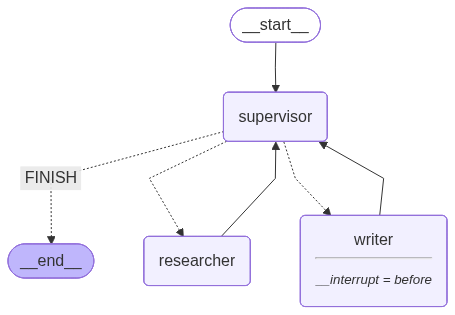

✅ Diagram rendered successfully.

Node list: ['__start__', 'supervisor', 'researcher', 'writer', '__end__']
Edge list: [('__start__', 'supervisor'), ('researcher', 'supervisor'), ('supervisor', '__end__'), ('supervisor', 'researcher'), ('supervisor', 'writer'), ('writer', 'supervisor')]


In [6]:
# ─── EXTENSION TASK: Visualize the LangGraph multi-agent architecture ────────
# This cell must run AFTER Cell 4 (graph is compiled)

from IPython.display import Image, display

print('📊 Generating LangGraph architecture diagram...\n')

try:
    # Primary method — renders a Mermaid PNG of the compiled graph
    # Shows all nodes (supervisor, researcher, writer),
    # conditional edges, back-edges, and the interrupt_before breakpoint
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print('✅ Diagram rendered successfully.')

except Exception as e:
    print(f'⚠️  Mermaid PNG failed ({e})')
    print('Falling back to ASCII diagram:\n')
    # Fallback — plain text graph, works offline with no extra deps
    graph.get_graph().print_ascii()

# ── What you are seeing ──────────────────────────────────────────────────────
# Nodes  : __start__ → supervisor → researcher / writer → __end__
# Edges  : supervisor --[conditional]--> researcher | writer | FINISH(END)
#          researcher --[always]-------> supervisor
#          writer     --[always]-------> supervisor
# ⏸ Mark : writer node is marked with interrupt_before (human breakpoint)
print('\nNode list:', list(graph.get_graph().nodes.keys()))
print('Edge list:', [(e.source, e.target) for e in graph.get_graph().edges])

In [7]:
# ─── STEP 5: Run Phase 1 — execute until breakpoint ────────────────────────
config = {"configurable": {"thread_id": "workshop_user_1"}}
initial_input = {"task": "Impact of LPU architecture on AI inference speeds", "research_notes": [], "retry_count": 0, "draft": ""}

# 1. Start execution
print("--- STARTING GRAPH ---")
for event in graph.stream(initial_input, config, stream_mode="values"):
    if "next_node" in event:
        print(f"Moving to: {event['next_node']}")

# 2. Check if we hit a breakpoint (Pause)
snapshot = graph.get_state(config)
if snapshot.next:
    print(f"\n⏸️ SYSTEM PAUSED. Next step is: {snapshot.next}")
    print(f"Feedback from Supervisor: {snapshot.values['revision_feedback']}")

    # 3. Resume (Human says 'Go ahead')
    print("\n--- RESUMING AFTER PAUSE ---")
    #for event in graph.stream(None, config, stream_mode="values"):
    #    print("Finalizing...")

--- STARTING GRAPH ---
🧠 Supervisor is reviewing state...
Supervisor sees 0 notes and draft length 0
Moving to: researcher
🚀 Researcher is digging...
[{'title': 'LPU Unleashed: How Groq is Rewriting AI Inference', 'url': 'https://www.baytechconsulting.com/blog/lpu-unleashed-groq-rewriting-ai-inference', 'content': "This 10x architectural advantage allows the LPU to feed its compute units at maximum speed, entirely bypassing the memory bottleneck. The data movement happens instantaneously on the silicon, driving unprecedented Time-to-First-Token (TTFT) metrics and overall throughput speeds that frequently exceed human reading capabilities by an order of magnitude. From an environmental and operational perspective, this localized data movement also renders the LPU up to 10x more energy-efficient than traditional GPUs for inference workloads. Furthermore, the LPU and its accompanying GroqRack systems are air-cooled by design, eliminating the need for the complex, hyper-expensive liquid co

In [8]:
# ─── STEP 6: Run Phase 2 — resume after human review ───────────────────────
print("--- RESUMING GRAPH ---\n")
for event in graph.stream(None, config, stream_mode="values"):
    if "next_node" in event:
        print(f"Moving to: {event['next_node']}")
    elif "draft" in event:
        print(f"\n--- FINAL DRAFT ---:\n{event['draft']}")

--- RESUMING GRAPH ---

Moving to: writer
✍️ Writer is composing...
Moving to: writer
🧠 Supervisor is reviewing state...
Supervisor sees 1 notes and draft length 3477
Moving to: writer
